## Oceanic currents

This notebook analyses the influence of sea surface velocity on MP concentration in sea sediments. The sea surface velocities were taken from Copernicus Marine Service (https://data.marine.copernicus.eu/product/GLOBAL_ANALYSISFORECAST_PHY_001_024/services). Mean over one year (01/03/2020-01/03/2021) is computed.

In [1]:
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

## Mean velocity at each site

In [2]:
ds = nc.Dataset('inputs\cmems_mod_glo_phy-cur_anfc_0.083deg_P1M-m_1777967505803.nc')

In [3]:
print(ds.variables["latitude"][:].min(), ds.variables["latitude"][:].max())
print(ds.variables["longitude"][:].min(), ds.variables["longitude"][:].max())

-80.0 89.666664
-180.0 179.91669


In [5]:
data = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
data.head()

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1


In [6]:
latitudes_data  = np.array(data["Lat_center"], dtype=float)
longitudes_data = np.array(data["Lon_center"], dtype=float)

points_data = list(zip(latitudes_data, longitudes_data))
# Format: (latitude, longitude, "Label")

lats_data   = [p[0] for p in points_data]
lons_data   = [p[1] for p in points_data]


In [7]:

lats = ds.variables["latitude"][:]
lons = ds.variables["longitude"][:]
uo = ds.variables["uo"][:]  # shape: (13, 1, 270, 241)
vo = ds.variables["vo"][:]

# Mean over time, squeeze depth
uo_mean = np.mean(uo, axis=0)[0, :, :]  # shape: (270, 241)
vo_mean = np.mean(vo, axis=0)[0, :, :]

# For each of your coordinates, find nearest grid point
results = []
for lat, lon in zip(lats_data, lons_data):
    i_lat = np.argmin(np.abs(lats - lat))
    i_lon = np.argmin(np.abs(lons - lon))

    results.append({
        "latitude": lat,
        "longitude": lon,
        "uo_mean": uo_mean[i_lat, i_lon],
        "vo_mean": vo_mean[i_lat, i_lon]
    })

df_velocity = pd.DataFrame(results)

In [8]:
df_velocity

,latitude,longitude,uo_mean,vo_mean
0,-74.5,163.5,--,--
1,-74.5,164.5,--,--
2,-42.5,147.5,--,--
3,-38.5,144.5,0.009819,0.014671
4,-35.5,138.5,--,--
...,...,...,...,...
99,73.5,-169.5,-0.044297,-0.005979
100,73.5,-168.5,-0.052321,0.013046
101,74.5,-173.5,-0.029429,0.013456
102,75.5,-179.5,-0.02812,0.013522


In [9]:
data_points = pd.concat([data, df_velocity['uo_mean'],df_velocity['vo_mean']], axis=1)

In [10]:
data_points

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,uo_mean,vo_mean
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,--,--
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,--,--
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,--,--
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,0.009819,0.014671
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,--,--
...,...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,-0.044297,-0.005979
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,-0.052321,0.013046
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,-0.029429,0.013456
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,-0.02812,0.013522


In [11]:
data_points['uo_mean'] = data_points['uo_mean'].apply(lambda x: np.nan if isinstance(x, np.ma.core.MaskedConstant) else x).astype(float)
data_points['vo_mean'] = data_points['vo_mean'].apply(lambda x: np.nan if isinstance(x, np.ma.core.MaskedConstant) else x).astype(float)

In [12]:
data_points.to_csv('outputs\Current velocity dataset.csv',index=False)

In [13]:
# Normalize data for statistics
data_points_copy = data_points.copy()
cols_to_normalize = [
                     'MEAN MP stock (g/m2) in 2021',
                     'uo_mean',	'vo_mean']

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])
# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]

In [14]:
variables = ['MEAN MP stock (g/m2) in 2021']

C:\Users\nelad\AppData\Local\Temp\ipykernel_1992\3180323329.py:30: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[n, 0].scatter(subset['uo_mean'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
C:\Users\nelad\AppData\Local\Temp\ipykernel_1992\3180323329.py:35: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[n, 1].scatter(subset['uo_mean'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])


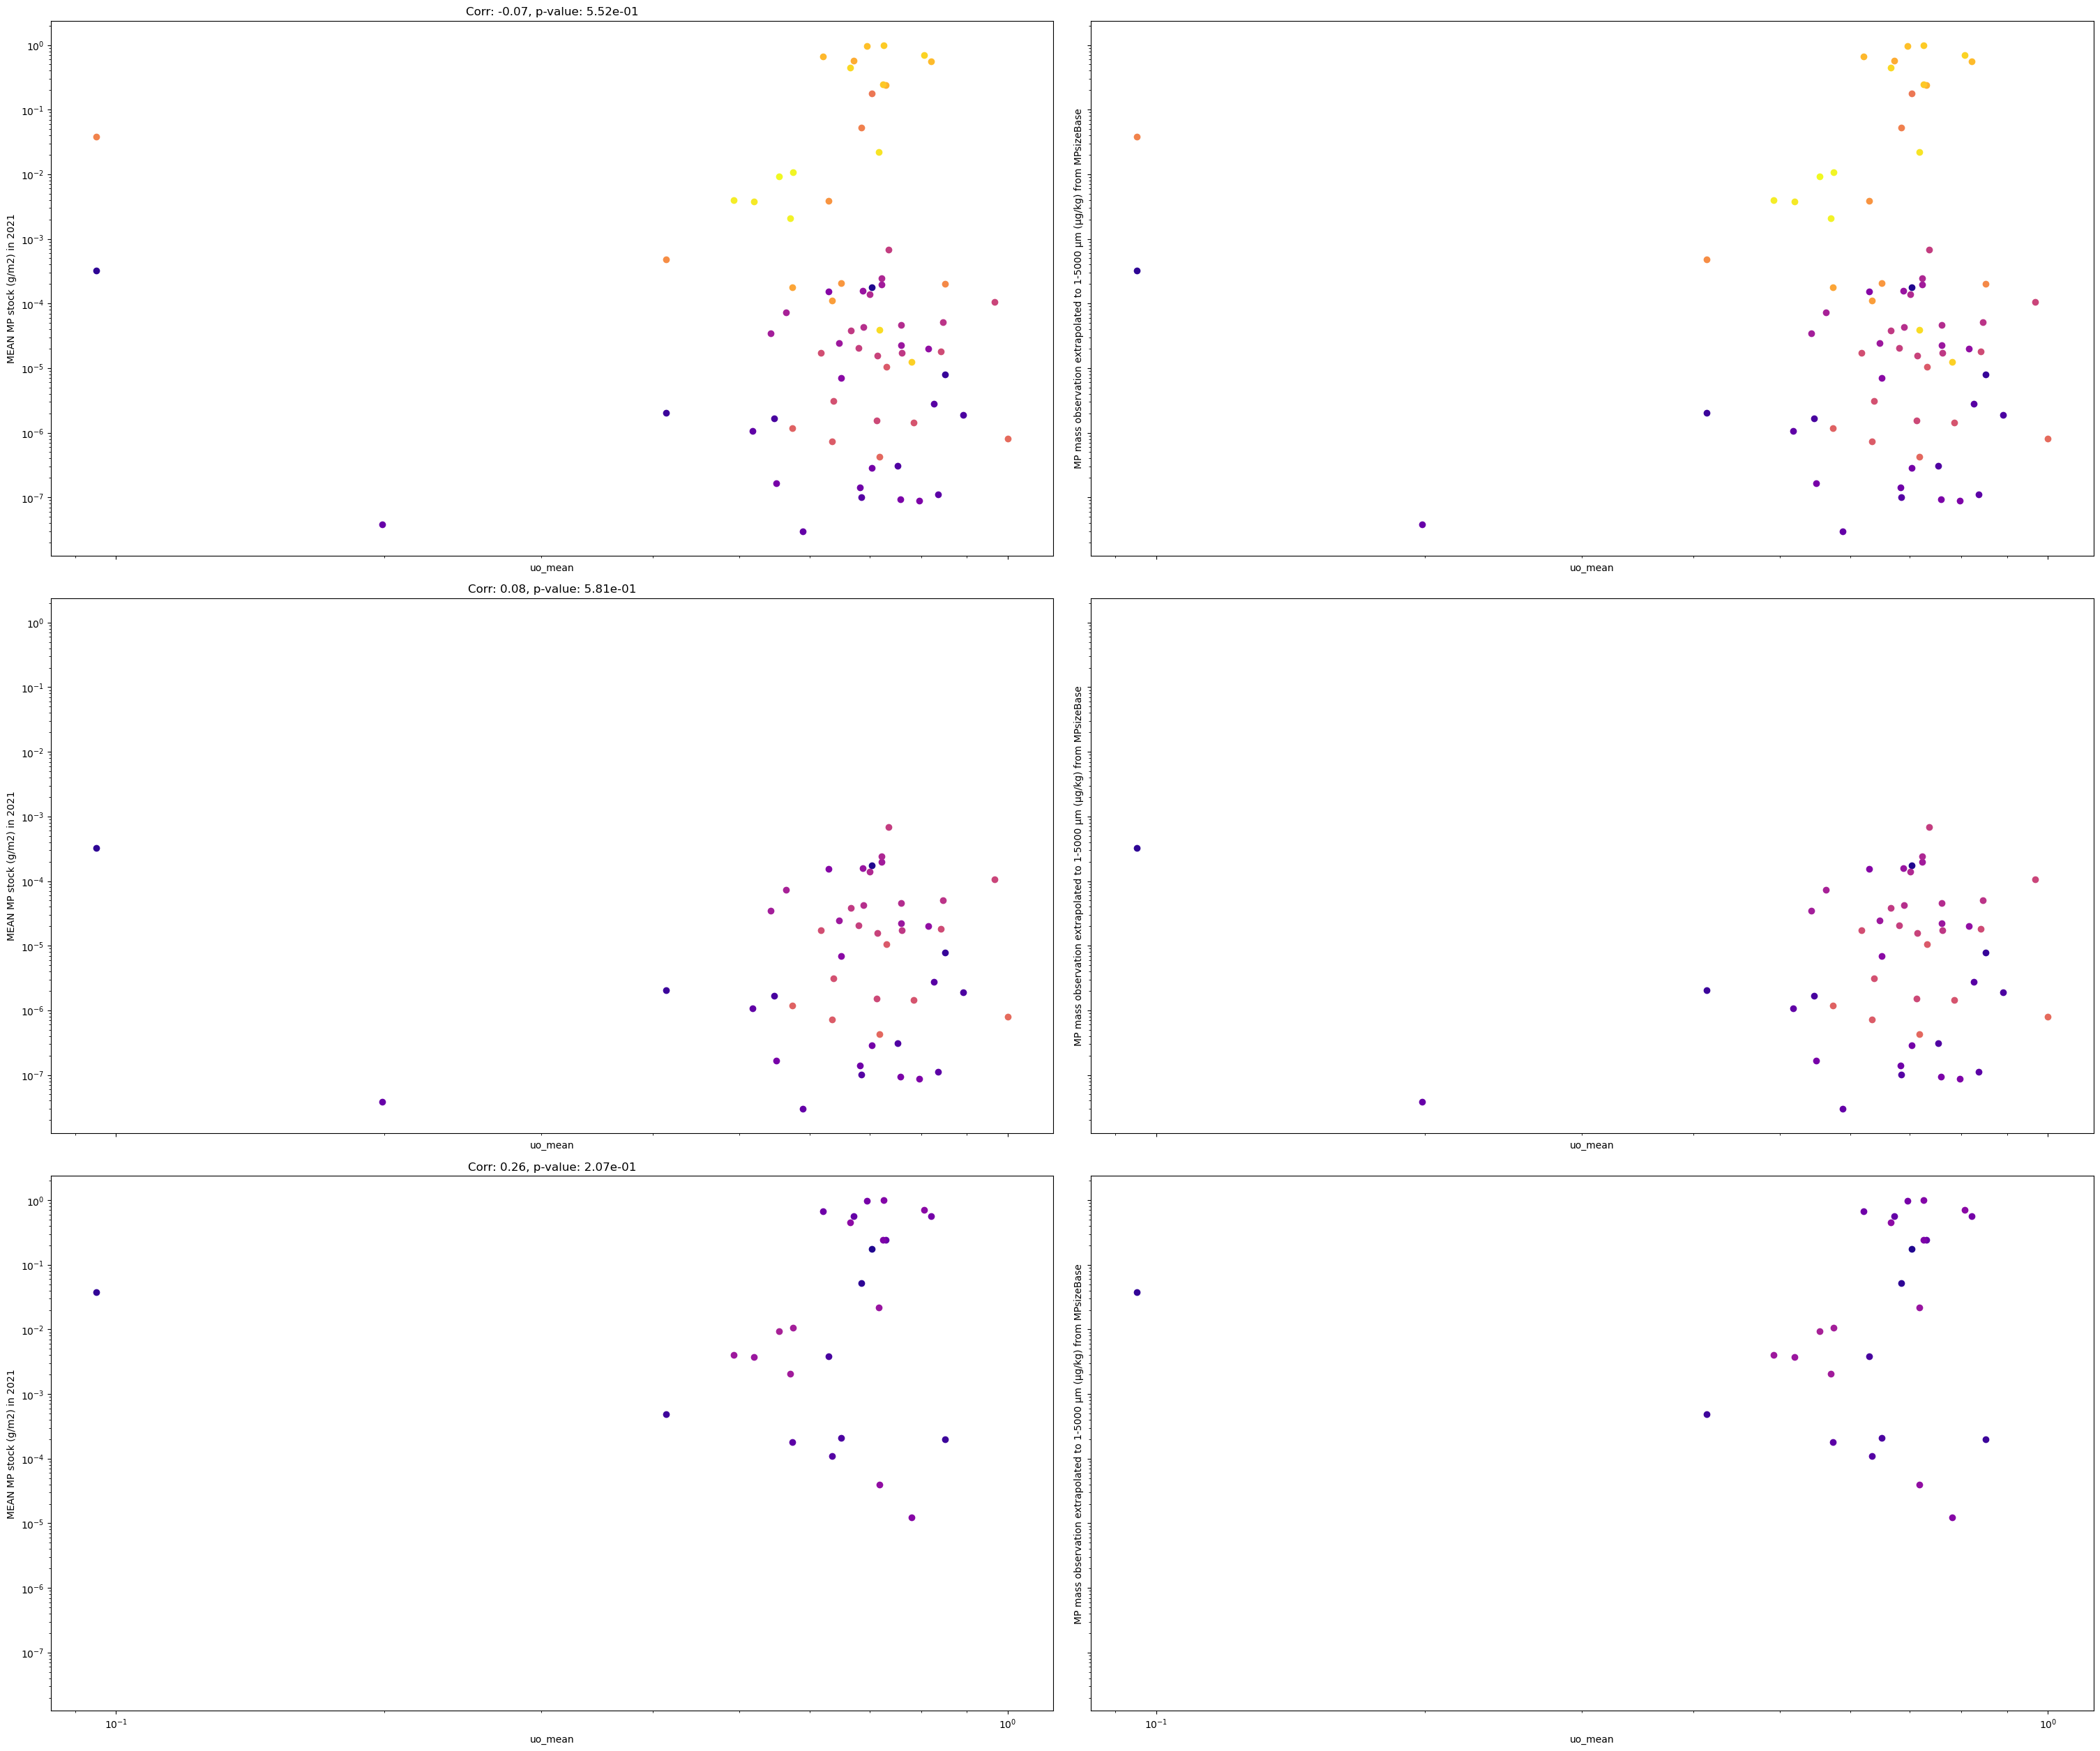

In [15]:

datasets = [data_points_copy,data_points_fib,data_points_frg]
sh = ['Both', 'Fibers', 'Fragments']


cmap = plt.colormaps['plasma']

data_points_copy["Author"] = data_points_copy.index
colors = cmap(np.linspace(0, 1, len(data_points_copy["Author"].unique())))

fig, axs = plt.subplots(3, 2, sharex=True, sharey=True, layout="constrained",figsize=(30, 25))
spearman_results = []
n = 0
for dataset in datasets:

    dataset["Author"] = dataset.index
    
    x = dataset['uo_mean']    
    y = dataset['MEAN MP stock (g/m2) in 2021']

    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'uo_mean stock {sh[n]}', spearman_stock[0], spearman_stock[1]))


    for i, author in enumerate(dataset["Author"].unique()):
            
        subset = dataset[dataset["Author"] == author]

        axs[n, 0].scatter(subset['uo_mean'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
        axs[n, 0].set_xlabel('uo_mean')
        axs[n, 0].set_ylabel('MEAN MP stock (g/m2) in 2021')
        axs[n, 0].set_title(f"Corr: {spearman_stock[0]:.2f}, p-value: {spearman_stock[1]:.2e}")
            
        axs[n, 1].scatter(subset['uo_mean'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
        axs[n, 1].set_xlabel('uo_mean')
        axs[n, 1].set_ylabel('MP mass observation extrapolated to 1-5000 µm (µg/kg) from MPsizeBase')


    plt.xscale("log")
    plt.yscale("log")

    n = n+1

In [16]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats.sort_values(by = "Spearman Correlation")

,Parameter,Spearman Correlation,Spearman p-value
0,uo_mean stock Both,-0.069692,0.552424
1,uo_mean stock Fibers,0.080714,0.581418
2,uo_mean stock Fragments,0.256068,0.206711


C:\Users\nelad\AppData\Local\Temp\ipykernel_1992\2115625258.py:30: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[n, 0].scatter(subset['uo_mean'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
C:\Users\nelad\AppData\Local\Temp\ipykernel_1992\2115625258.py:35: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[n, 1].scatter(subset['uo_mean'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])


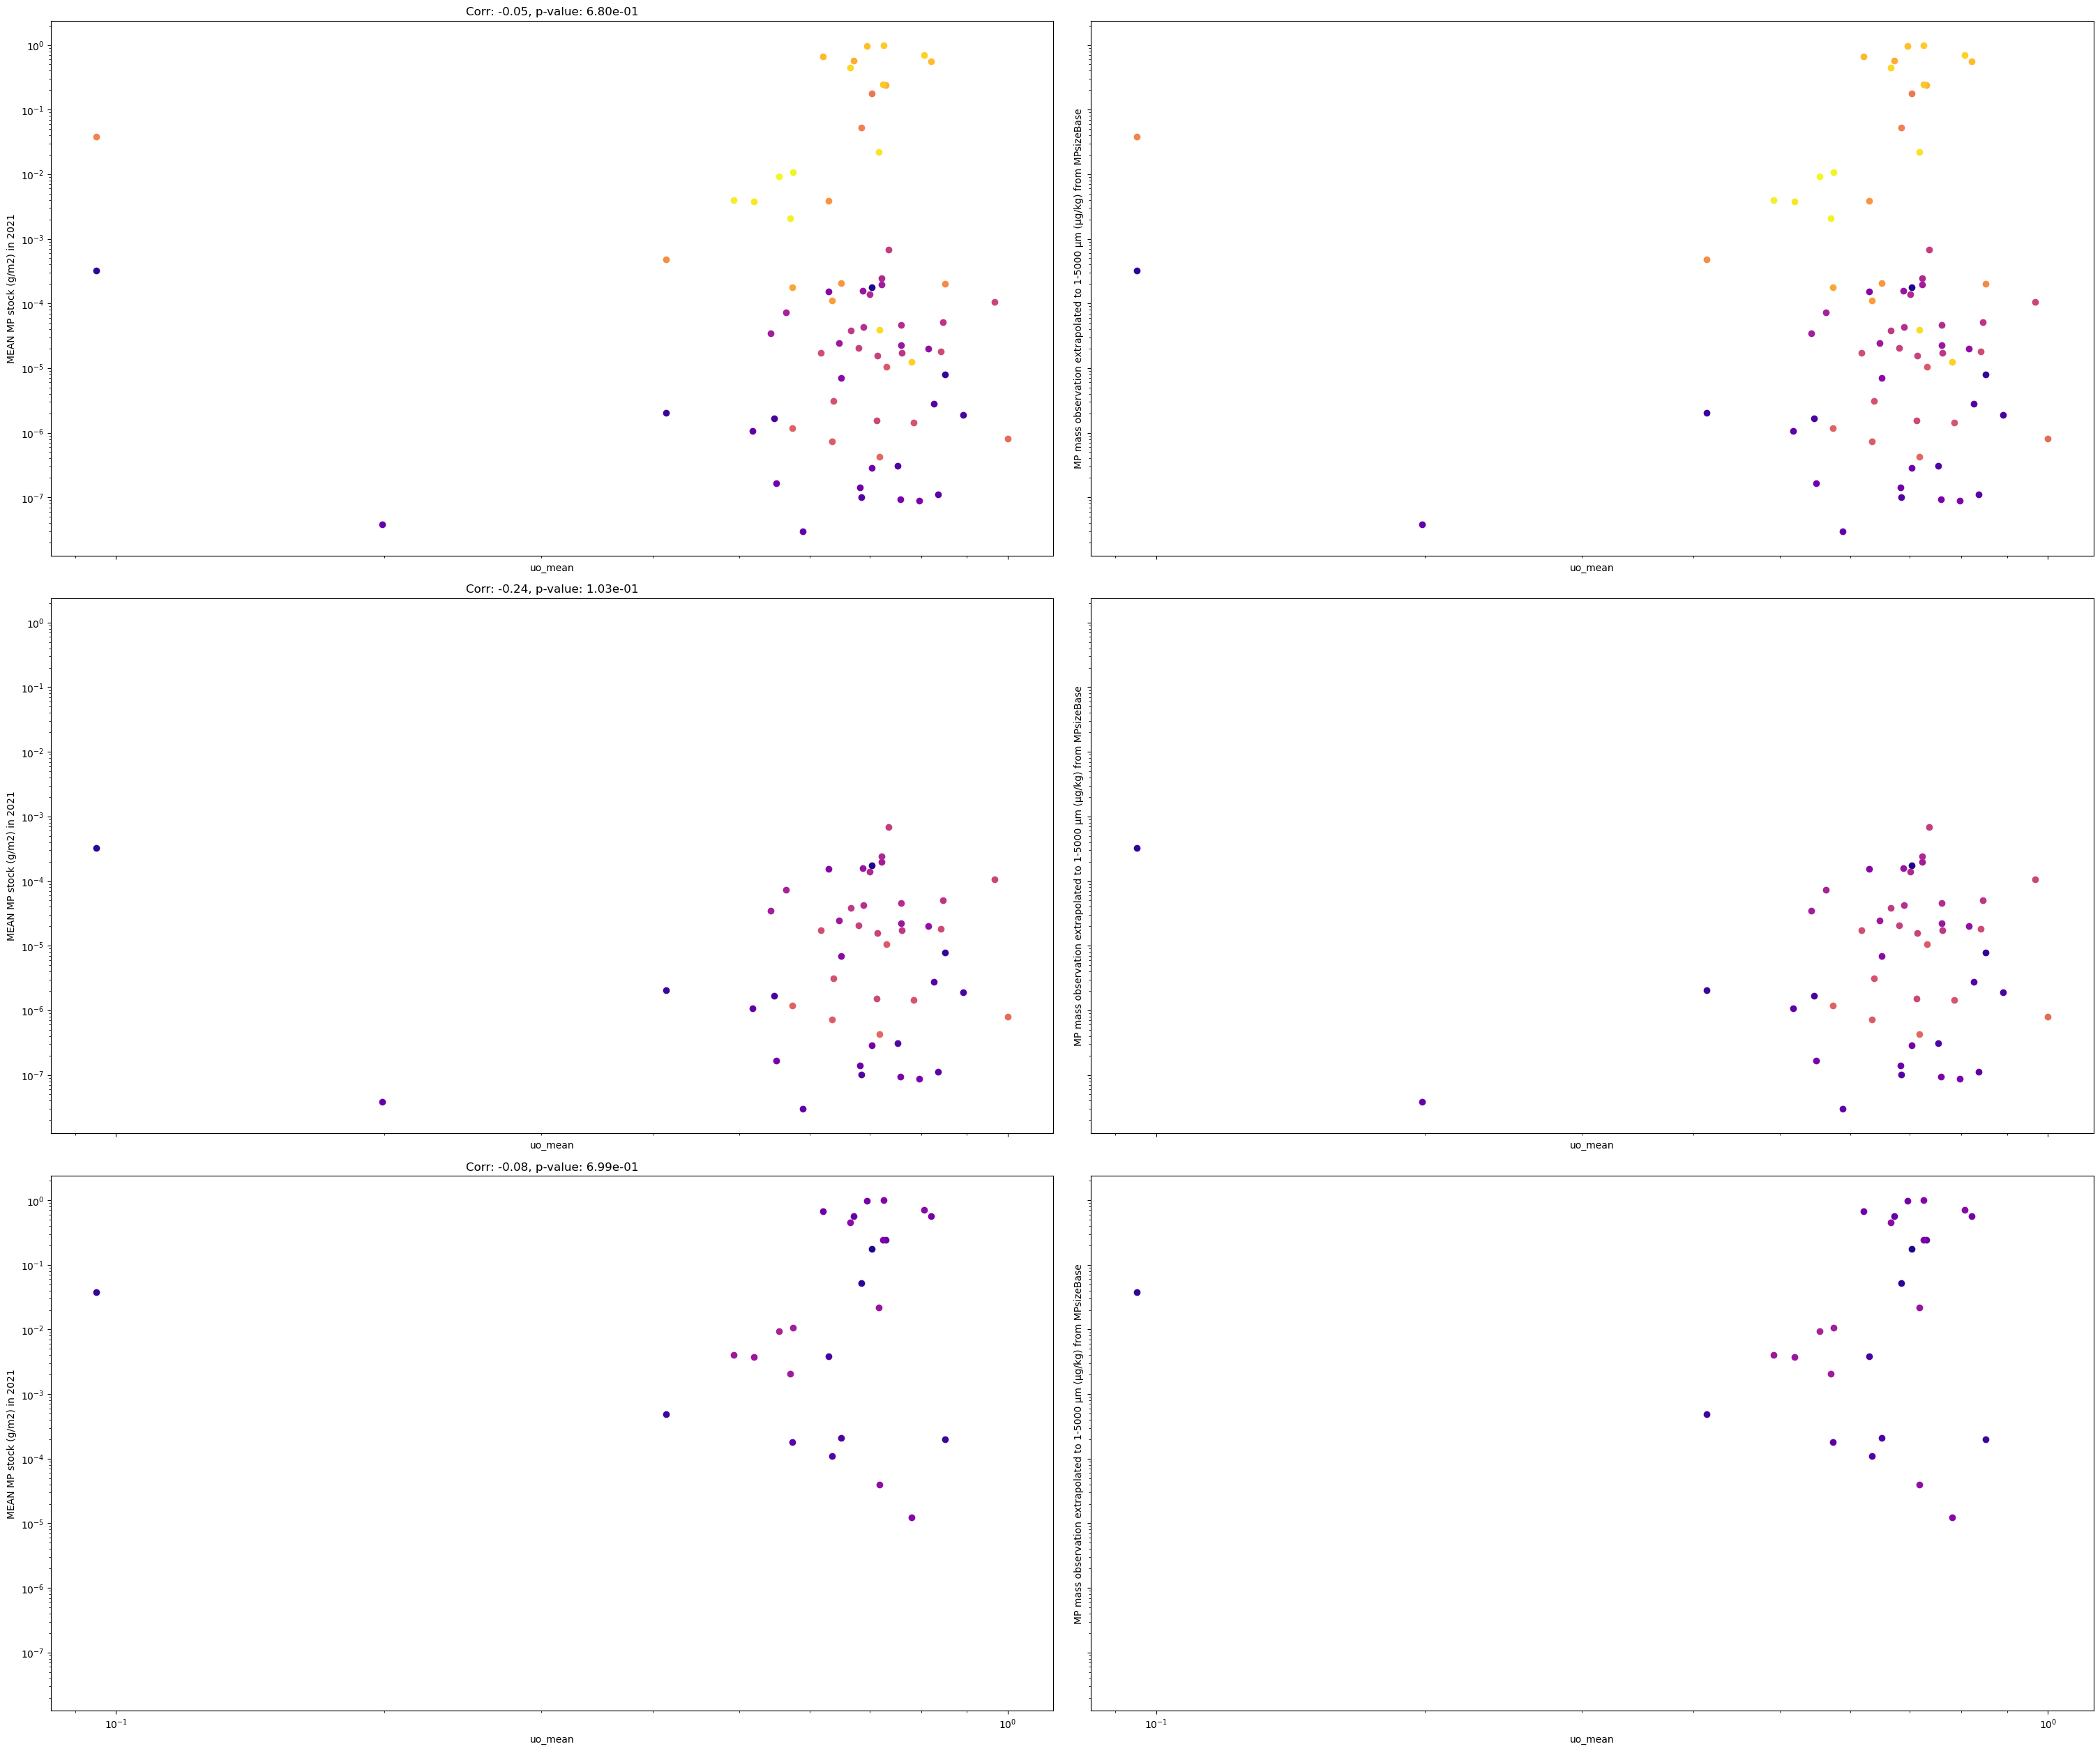

In [17]:

datasets = [data_points_copy,data_points_fib,data_points_frg]
sh = ['Both', 'Fibers', 'Fragments']


cmap = plt.colormaps['plasma']

data_points_copy["Author"] = data_points_copy.index
colors = cmap(np.linspace(0, 1, len(data_points_copy["Author"].unique())))

fig, axs = plt.subplots(3, 2, sharex=True, sharey=True, layout="constrained",figsize=(30, 25))
spearman_results = []
n = 0
for dataset in datasets:

    dataset["Author"] = dataset.index
    
    x = dataset['vo_mean']    
    y = dataset['MEAN MP stock (g/m2) in 2021']

    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'uo_mean stock {sh[n]}', spearman_stock[0], spearman_stock[1]))


    for i, author in enumerate(dataset["Author"].unique()):
            
        subset = dataset[dataset["Author"] == author]

        axs[n, 0].scatter(subset['uo_mean'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
        axs[n, 0].set_xlabel('uo_mean')
        axs[n, 0].set_ylabel('MEAN MP stock (g/m2) in 2021')
        axs[n, 0].set_title(f"Corr: {spearman_stock[0]:.2f}, p-value: {spearman_stock[1]:.2e}")
            
        axs[n, 1].scatter(subset['uo_mean'], subset['MEAN MP stock (g/m2) in 2021'], c=colors[i])
        axs[n, 1].set_xlabel('uo_mean')
        axs[n, 1].set_ylabel('MP mass observation extrapolated to 1-5000 µm (µg/kg) from MPsizeBase')


    plt.xscale("log")
    plt.yscale("log")

    n = n+1

In [18]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats.sort_values(by = "Spearman Correlation")

,Parameter,Spearman Correlation,Spearman p-value
1,uo_mean stock Fibers,-0.236020,0.102543
2,uo_mean stock Fragments,-0.079658,0.698891
0,uo_mean stock Both,-0.048438,0.679837
